### importing libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv("data/Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Basic exploration

In [3]:
df.shape
df.info()
df.describe().T
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

### EDA

In [4]:
df.duplicated().sum()

np.int64(0)

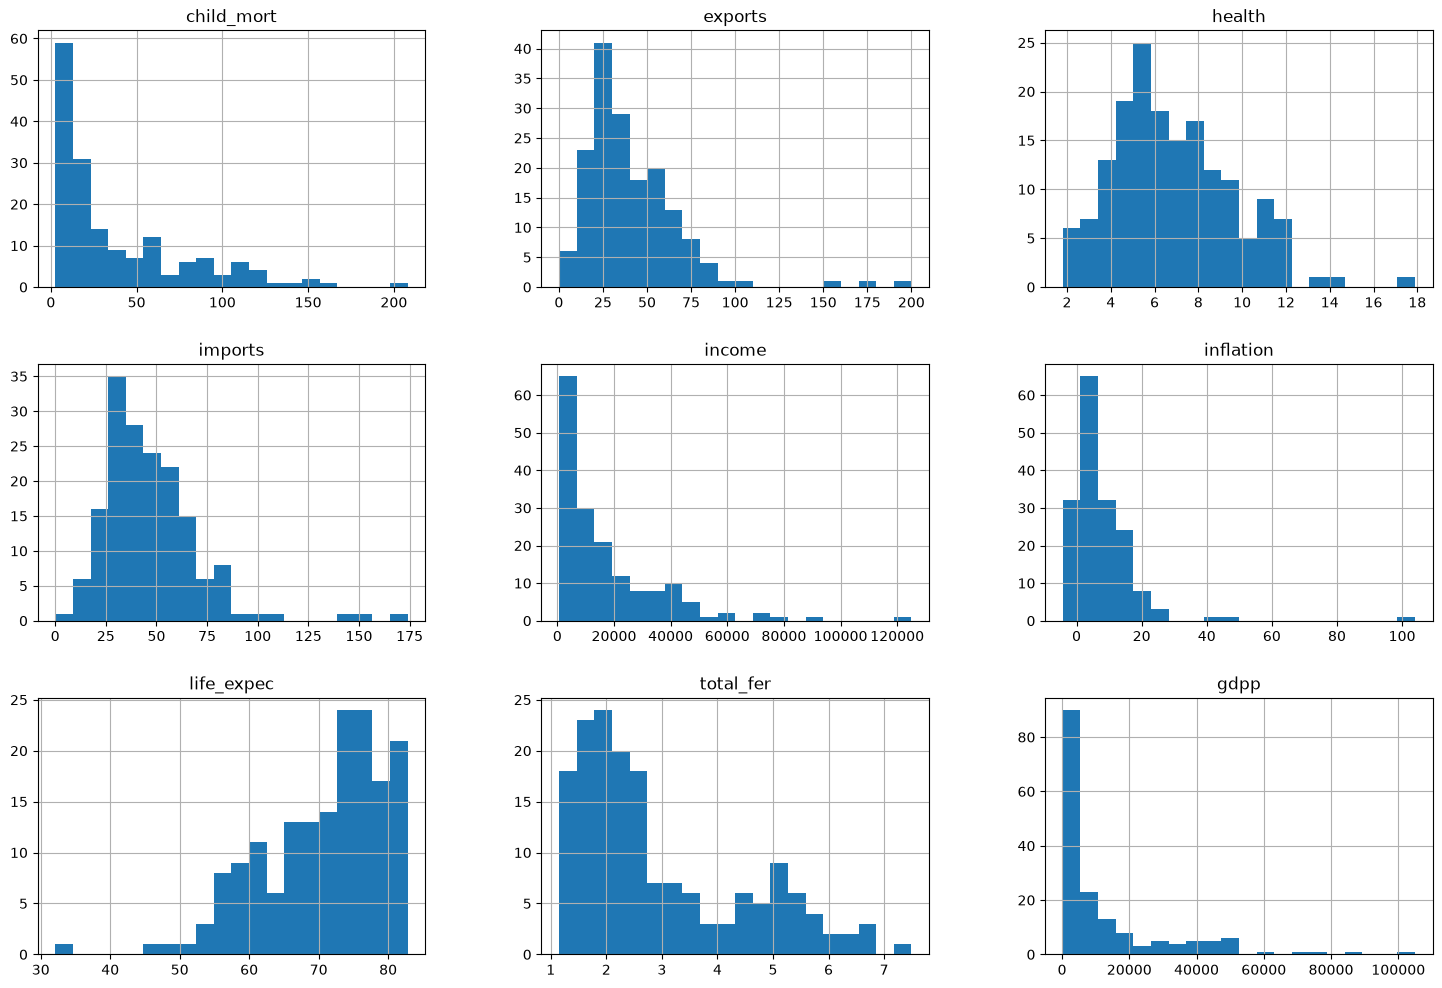

In [5]:
df.hist(figsize=(18,12), bins=20)
plt.show()

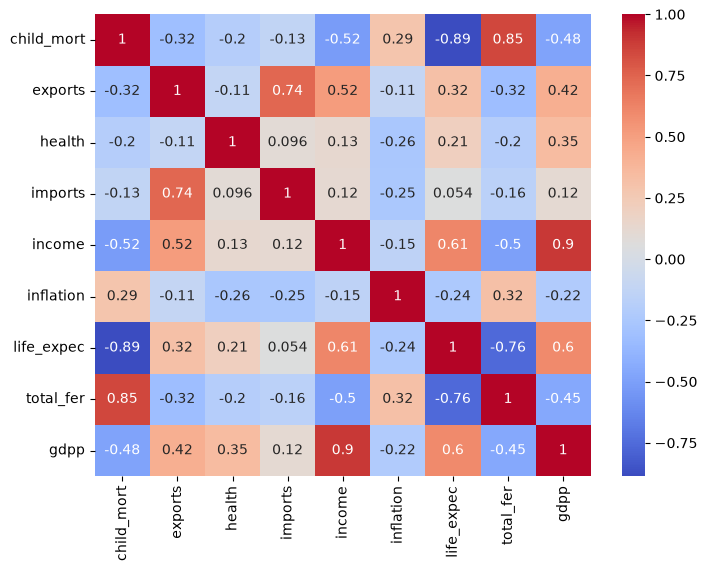

In [6]:
plt.figure(figsize=(8,6))

sns.heatmap(df.drop("country",axis=1).corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

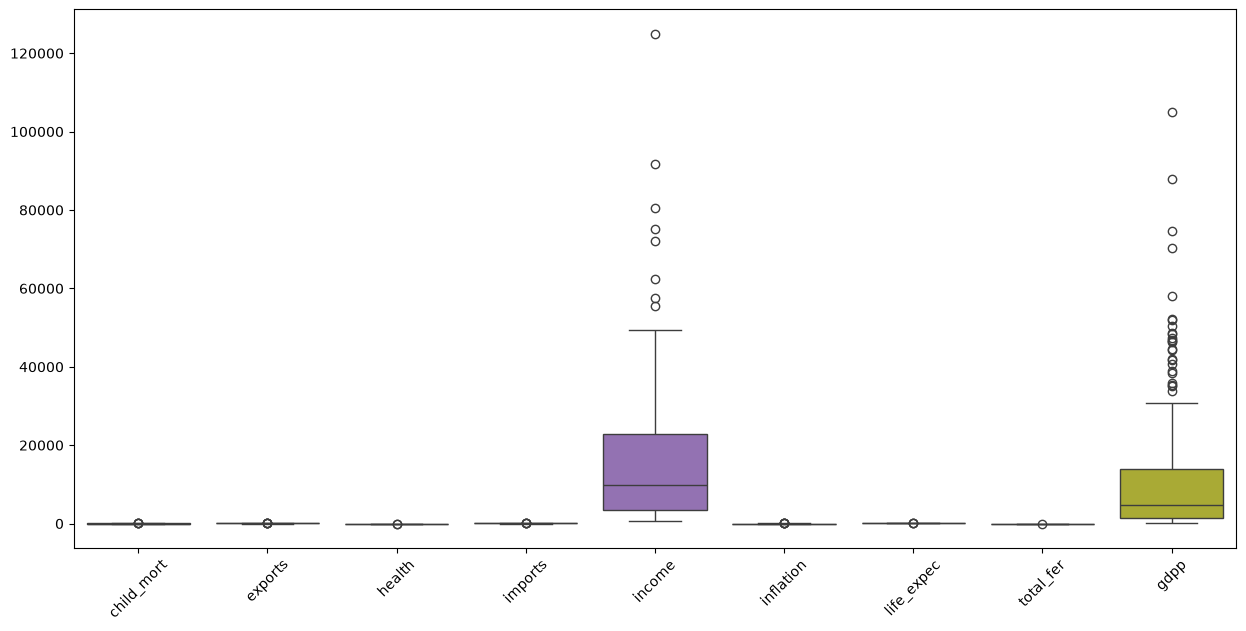

In [7]:
plt.figure(figsize=(15,7))

sns.boxplot(data=df.drop("country",axis=1))

plt.xticks(rotation=45)

plt.show()

### Feature Scaling and Data Modeling

In [8]:
X = df.drop("country",axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

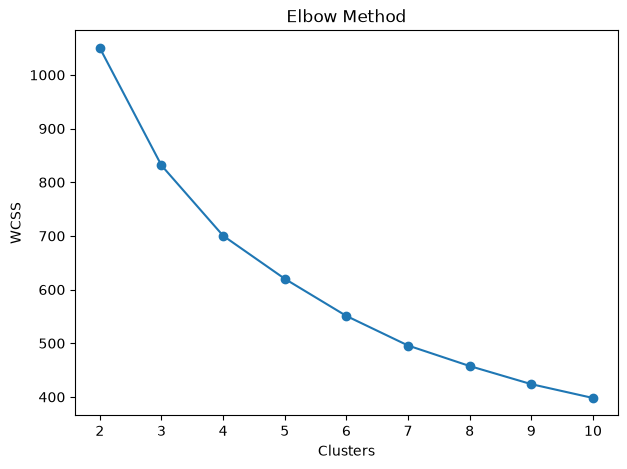

In [9]:
# choosing k value for k-means -> Elbow method
inertia=[]

for k in range(2,11):

    km=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    km.fit(X_scaled)

    inertia.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(2,11),inertia,marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

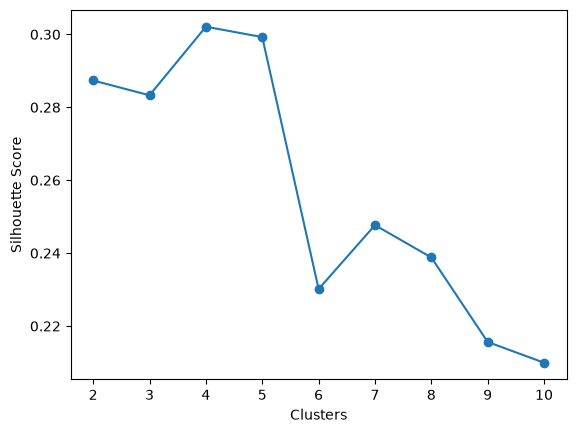

In [10]:
# Silhouette Score
scores=[]

for k in range(2,11):

    km=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels=km.fit_predict(X_scaled)

    scores.append(silhouette_score(X_scaled,labels))

plt.plot(range(2,11),scores,marker='o')
plt.xlabel("Clusters")
plt.ylabel("Silhouette Score")
plt.show()

### Hierarchical Clustering Validation

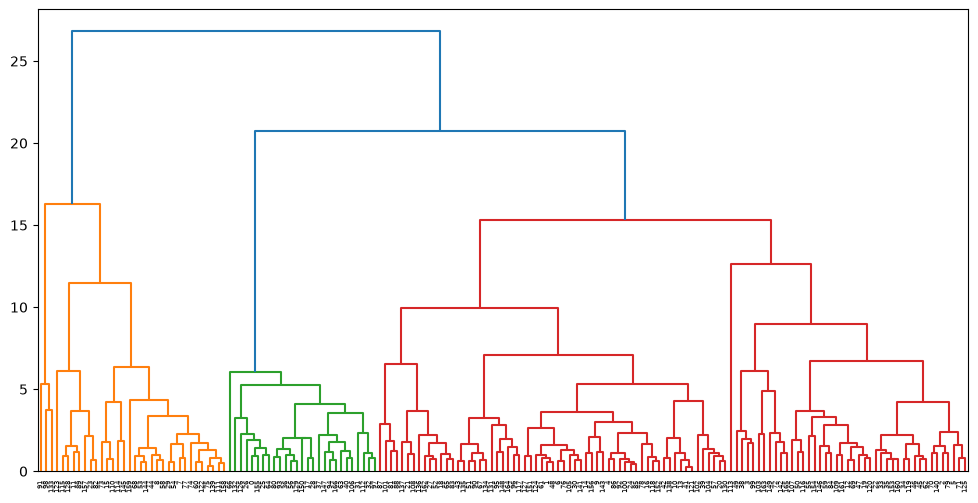

In [11]:
linked = linkage(X_scaled,'ward')
plt.figure(figsize=(12,6))
dendrogram(linked)
plt.show()

### Training k-means

In [12]:
kmeans=KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

df["Cluster"]=kmeans.fit_predict(X_scaled)

In [13]:
df["Cluster"].value_counts()

Cluster
2    84
1    47
0    36
Name: count, dtype: int64

In [14]:
cluster_summary=df.groupby("Cluster").mean(numeric_only=True)
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


### Cluster Visualization using PCA

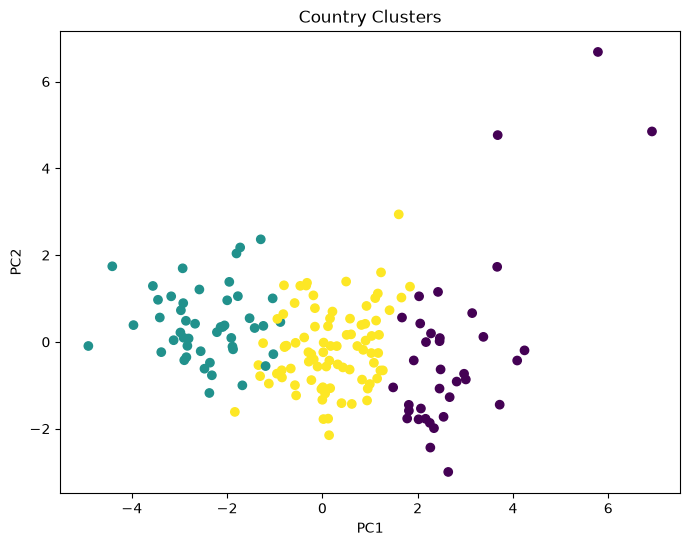

In [15]:
pca=PCA(n_components=2)

components=pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    components[:,0],
    components[:,1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Country Clusters")

plt.show()

### DBSCAN

In [16]:
db=DBSCAN(
    eps=1.5,
    min_samples=5
)

df["DBSCAN"]=db.fit_predict(X_scaled)

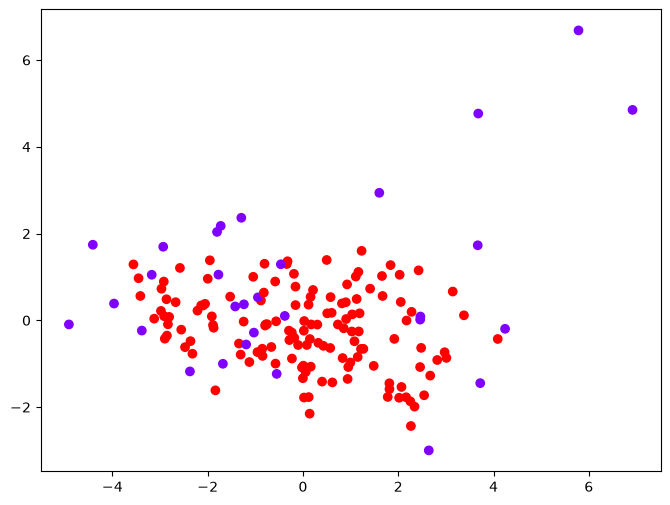

In [17]:
# visualisation
plt.figure(figsize=(8,6))

plt.scatter(
    components[:,0],
    components[:,1],
    c=df["DBSCAN"],
    cmap="rainbow"
)

plt.show()

### Countries in each cluster

In [18]:
for i in sorted(df.Cluster.unique()):

    print(f"\nCluster {i}")

    print(df[df.Cluster==i]["country"].tolist())


Cluster 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']

Cluster 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'To

In [19]:
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


### Ranking Neediest Countries

In [20]:
need_df=df[df.Cluster==1].copy()

need_df["Need Score"]=(
      need_df["child_mort"]
    + need_df["inflation"]
    + need_df["total_fer"]
    - need_df["income"]/1000
    - need_df["gdpp"]/1000
    + (100-need_df["life_expec"])
)

need_df.sort_values(
    "Need Score",
    ascending=False
)[["country","Need Score"]].head(20)

,country,Need Score
66,Haiti,282.518
113,Nigeria,271.860
132,Sierra Leone,225.781
31,Central African Republic,207.386
32,Chad,203.653
97,Mali,185.842
37,"Congo, Dem. Rep.",184.897
3,Angola,178.030
112,Niger,173.078
63,Guinea,170.602


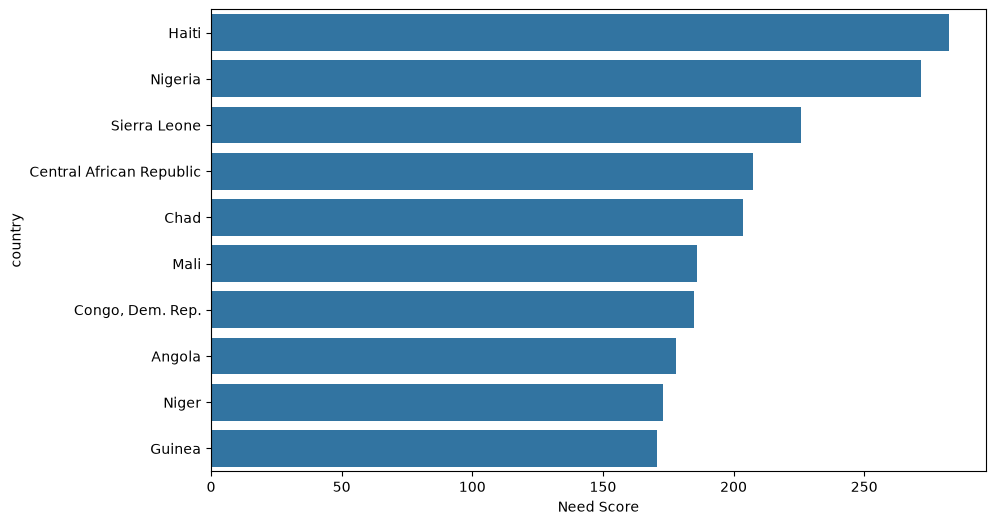

In [21]:
# Visualize
top=need_df.sort_values(
    "Need Score",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top,
    x="Need Score",
    y="country"
)

plt.show()

## Cluster Analysis and Interpretation

The K-Means clustering algorithm segmented the countries into **three distinct clusters** based on their socio-economic and health indicators. The average values of each feature for every cluster are shown above, allowing us to interpret the development level of each group.

### **Cluster 0 – Highly Developed Countries**
Countries in Cluster 0 exhibit the strongest socio-economic indicators and are the least in need of external aid.

**Key Characteristics:**
- Lowest child mortality (**5.0**)
- Highest average income (**45,672**)
- Highest GDP per capita (**42,494**)
- Highest life expectancy (**80.13 years**)
- Lowest fertility rate (**1.75**)
- Lowest inflation (**2.67%**)

These countries have stable economies, advanced healthcare systems, and high standards of living. Therefore, they should not be prioritized for financial assistance.

---

### **Cluster 1 – Least Developed Countries (Highest Priority)**
Cluster 1 represents countries facing severe socio-economic and health challenges. These nations should be considered the **highest priority** for HELP International's aid.

**Key Characteristics:**
- Highest child mortality (**92.96**)
- Lowest average income (**3,942**)
- Lowest GDP per capita (**1,922**)
- Lowest life expectancy (**59.19 years**)
- Highest fertility rate (**5.01**)
- Highest inflation (**12.02%**)

These indicators suggest poor healthcare infrastructure, widespread poverty, and economic instability. Since this cluster performs the worst across nearly every development indicator, it represents the countries in the greatest need of humanitarian and financial support.

---

### **Cluster 2 – Developing Countries**
Countries in Cluster 2 fall between the developed and least developed groups. Their socio-economic indicators are moderate, indicating developing economies with improving living conditions.

**Key Characteristics:**
- Moderate child mortality (**21.93**)
- Moderate income (**12,306**)
- Moderate GDP per capita (**6,486**)
- Life expectancy of approximately **72.81 years**
- Moderate fertility rate (**2.31**)
- Moderate inflation (**7.60%**)

Although these countries may still require targeted development programs, they are generally in a better position than those in Cluster 1.

---

## Conclusion

Based on the clustering results, **Cluster 1** should be the primary focus of HELP International. The countries in this cluster consistently exhibit:
- Very low income and GDP per capita,
- High child mortality,
- Low life expectancy,
- High fertility rates, and
- High inflation.

These characteristics indicate the greatest level of socio-economic vulnerability. Therefore, the NGO should prioritize countries belonging to **Cluster 1** for the allocation of the available \$10 million in aid, ensuring that resources are directed toward the nations with the most urgent developmental needs.